In [37]:
!pip install xgboost

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
    --------------------------------------- 1.6/72.0 MB 9.0 MB/s eta 0:00:08
   -- ------------------------------------- 3.9/72.0 MB 9.8 MB/s eta 0:00:07
   -- ------------------------------------- 5.0/72.0 MB 8.0 MB/s eta 0:00:09
   ---- ----------------------------------- 7.3/72.0 MB 8.7 MB/s eta 0:00:08
   ----- ---------------------------------- 9.4/72.0 MB 9.1 MB/s eta 0:00:07
   ----- ---------------------------------- 10.7/72.0 MB 9.1 MB/s eta 0:00:07
   ------- -------------------------------- 13.4/72.0 MB 9.1 MB/s eta 0:00:07
   -------- ------------------------------- 15.7/72.0 MB 9.4 MB/s eta 0:00:07
   --------- ------------------------------ 17.8/72.0 MB 9.5 MB/s eta 0:00:06
   ----------- ---------------------------- 20.2/72.0 MB 9.6 MB/s eta 0:00:06
   ------------ --------------------------- 22.3/72.0 MB 9.7 MB/s eta 0:00:06
   ------------- -------------------------- 24.6/72.0 MB 9.8 MB/s eta 0:00:05

In [49]:
class Dataset:
    def __init__(self,image_path):
        self.image_path=image_path
    def compute_otsuscore(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        resized_img = cv2.resize(image, (256, 256))
        hist=cv2.calcHist([resized_img], [0], None, [256], [0, 256]).ravel()
        hist_norm=hist/hist.sum()
        cum_sum=np.cumsum(hist_norm)
        cum_mean = np.cumsum(np.arange(256) * hist_norm)
        global_mean=cum_mean[-1]
        sigma_b_mean = ((global_mean * cum_sum - cum_mean) ** 2) / (cum_sum * (1 - cum_sum) + 1e-7)
        return sigma_b_mean[np.argmax(sigma_b_mean)]
    def compute_fft(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        ft=np.fft.fft2(image)
        ft_shift=np.fft.fftshift(ft)
        magnitude_spectrum = 20 * np.log(np.abs(ft_shift) + 1)
        return np.mean(magnitude_spectrum)  
    def laplace_variance(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        laplace_img=cv2.Laplacian(image,cv2.CV_64F)
        return laplace_img.var()
    def gradient_energy(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        gx,gy=np.gradient(image)
        energy=gx**2 + gy**2
        return np.mean(energy) 
    def michelson_contrast(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        image = image.astype(np.float64)
        min_val=np.min(image)
        max_val=np.max(image)
        y=max_val+min_val
        if y==0 or np.isinf(y) or np.isnan(y):
            return 0.0
        contrast=(max_val- min_val) / (max_val + min_val)
        return contrast
    def canny_edge_count(self):
        image=cv2.imread(self.image_path,cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError(f"Could not load image from {image_path}")
        edges=cv2.Canny(image, threshold1=30, threshold2=100)
        return np.count_nonzero(edges)

In [50]:
import os
import cv2
import numpy as np
import pandas as pd
from random import shuffle

def load_(d:Dataset,image_dir):
  
    all_images = [f for f in os.listdir(image_dir) 
                  if os.path.isfile(os.path.join(image_dir, f))]

    shuffle(all_images)
    train_count = int(0.7 * len(all_images))
    train_images = all_images[:train_count]

    results = []

    for img_name in train_images:
        image_path = os.path.join(image_dir, img_name)

        d = Dataset(image_path)

        img_dict = {
            'otsu_score': d.compute_otsuscore(),
            'fft': d.compute_fft(),
            'variance': d.laplace_variance(),
            'gradient_energy': d.gradient_energy(),
            'michaelson_contrast': d.michelson_contrast(),
            'canny_edge': d.canny_edge_count()
        }

        results.append(img_dict)

    return pd.DataFrame(results)


In [51]:
image_path= r"D:\COMPUTER_VISION\anomaly_detection_test_data\anomaly_detection_test_data\bad"
d=Dataset(image_path)
df_bad_train=load_(d,image_path)
image_path= r"D:\COMPUTER_VISION\anomaly_detection_test_data\anomaly_detection_test_data\good"
d=Dataset(image_path)
df_good_train=load_(d,image_path)
df_bad_train['label'] = 0   
df_good_train['label'] = 1  


In [52]:
df_train = pd.concat([df_bad_train, df_good_train], ignore_index=True)


In [53]:
df_train

,otsu_score,fft,variance,gradient_energy,michaelson_contrast,canny_edge,label
0,5015.487652,130.780430,304.577230,282.050305,0.598746,1605,0
1,7731.910035,133.036576,146.141257,212.916713,0.795775,2678,0
2,6845.997323,124.440535,208.646950,310.632713,0.728814,1674,0
3,4299.185329,134.627861,209.096133,167.857610,0.545455,2064,0
4,7817.179328,140.738964,490.127493,377.613185,0.777003,2564,0
...,...,...,...,...,...,...,...
3620,7575.837581,139.046753,326.377571,282.704492,0.722973,2451,1
3621,7083.854289,122.448309,181.358282,291.978968,0.875000,1349,1
3622,6073.687748,122.051995,113.381526,127.633958,0.847826,2654,1
3623,7006.713697,119.267335,187.494661,336.401463,0.722973,1348,1


In [54]:
import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor

In [55]:
X_train=df_train.drop(columns='label')
y_train=df_train['label']
model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
model.fit(X_train, y_train)

C:\Users\wwwra\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:47:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [56]:
import os
import pandas as pd
from random import shuffle

def load_test(d:Dataset,image_dir, split='train', fraction=0.7):

    all_images = [f for f in os.listdir(image_dir) if os.path.isfile(os.path.join(image_dir, f))]
    shuffle(all_images)
    
    train_count = int(fraction * len(all_images))
    
    if split == 'train':
        selected_images = all_images[:train_count]
    elif split == 'val':
        selected_images = all_images[train_count:]
    else:
        raise ValueError("split must be 'train' or 'val'")
    
    results = []
    
    for img_name in selected_images:
        image_path = os.path.join(image_dir, img_name)
        d = Dataset(image_path)
        img_dict = {
            'otsu_score': d.compute_otsuscore(),
            'fft': d.compute_fft(),
            'variance': d.laplace_variance(),
            'gradient_energy': d.gradient_energy(),
            'michaelson_contrast': d.michelson_contrast(),
            'canny_edge': d.canny_edge_count()
        }
        results.append(img_dict)
    
    return pd.DataFrame(results)


In [57]:
image_path= r"D:\COMPUTER_VISION\anomaly_detection_test_data\anomaly_detection_test_data\bad"
d=Dataset(image_path)
df_bad_test=load_test(d,image_path)
image_path= r"D:\COMPUTER_VISION\anomaly_detection_test_data\anomaly_detection_test_data\good"
d=Dataset(image_path)
df_good_test=load_test(d,image_path)
df_bad_test['label'] = 0   
df_good_test['label'] = 1  


In [58]:
df_test = pd.concat([df_bad_test, df_good_test], ignore_index=True)
df_test

,otsu_score,fft,variance,gradient_energy,michaelson_contrast,canny_edge,label
0,7426.881146,123.551660,211.030863,325.351255,0.888889,2046,0
1,7505.835947,123.288033,214.331211,354.007604,0.868132,1817,0
2,6143.578137,122.611379,203.479902,294.237984,0.711409,1588,0
3,6174.209296,125.072912,257.249933,312.377813,0.821429,2037,0
4,1260.382782,130.779042,131.726710,45.892108,0.389646,2788,0
...,...,...,...,...,...,...,...
3620,7767.435420,131.532134,257.363574,333.612848,0.868132,1605,1
3621,4609.778982,123.928924,254.591393,270.930315,0.619048,2092,1
3622,5419.424623,115.291287,85.799347,137.741071,0.881919,2328,1
3623,3896.654742,115.370792,72.259152,121.267155,0.672131,2178,1


In [59]:
X_test=df_test.drop(columns='label')
y_test=df_test['label']

In [60]:
y_predict=model.predict(X_test)

In [63]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_predict)
print(report)


              precision    recall  f1-score   support

           0       0.96      0.95      0.96       716
           1       0.99      0.99      0.99      2909

    accuracy                           0.98      3625
   macro avg       0.98      0.97      0.97      3625
weighted avg       0.98      0.98      0.98      3625



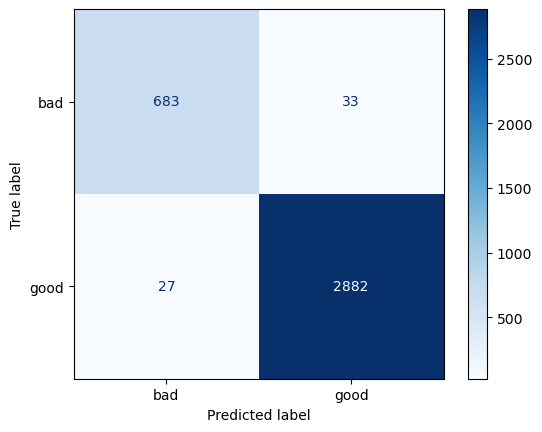

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test,y_predict)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['bad', 'good'])
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [65]:
import joblib

joblib.dump(model, 'classifier.pkl')



['classifier.pkl']